# Text Analysis Lesson

## Lesson Learning Outcome

* **The Text Analysis Lesson consists of one topic**
* By the end of this lesson, you should be able to:
  * Gather text data from Wikipedia
  * Create a WordCloud
  * Learn and use basic functionalities from Text Hero
  * Handle a DataFrame with Textual data

---

## Topic Objectives

  * Gather text data from Wikipedia
  * Create a WordCloud
  * Learn and use basic functionalities from Text Hero
  * Handle a DataFrame with Text data



---

* Data Analytics also has incredible applications when dealing with text. As part of this process, you will have to learn more about the words that are most common for a given subset of your data. 

* **Why do we study text analysis?**
  * Because it allows you to analyse words present in different classes of textual data and it quickly reveals significant insights to your project



## Additional Learning Context

* We encourage you to:
  * Add **code cells and try out** other possibilities, e.g., playing around with parameter values in a function/method, considering additional function parameters, etc.
  * Also, **add your own comment** in the cells. It can help you to consolidate your learning. 


* Parameters in given function/method
  * As you may expect, a given function in a package may contain multiple parameters. 
  * Some are mandatory to declare, some have pre-defined values, and some are optional. We will cover the most common parameters used/employed in Data Analytics for a particular function/method. 
  * However, you may seek additional in the respective package documentation, where you will find instructions on how to use a given function/method. The studied packages are open source, so this documentation is public.

---

## Import Package for Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

# Text Analysis

There might come a moment in the workplace that your dataset may contain text, for example: a long description about a given group or a product review. We will learn how to:
* Collect data from Wikipedia articles
* Create WordCloud 
* Use a text processing library called TextHero
* Handle text data in DataFrames

## Wikipedia

Let's dive into the exciting world of web scraping with the Wikipedia library. Our first step is to install the `Wikipedia` library for this exercise.

We will use `wikipedia.page()` to request data. The argument is the Wikipedia article name. 
* In this case, we are requesting the content from "Python_(programming_language)"

In [ ]:
import wikipedia
wiki_request = wikipedia.page('Python_(programming_language)')
wiki_request

You can access the attributes to choose your option

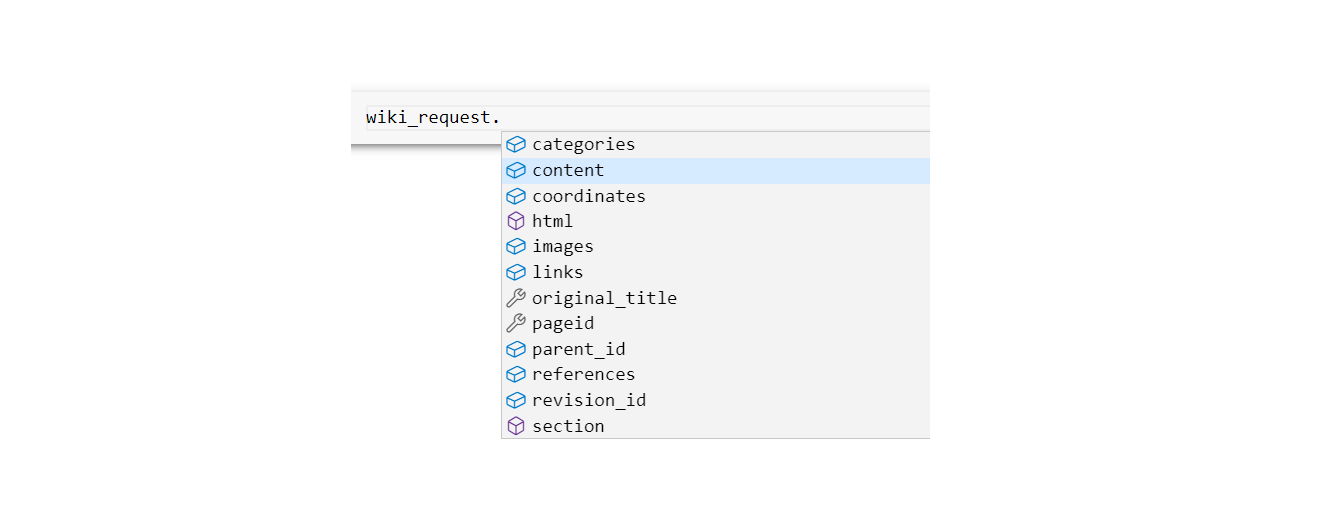

We are selecting `.content`, so we can access the article text


In [ ]:
text = wiki_request.content
text

Let's check the text length

In [ ]:
len(text)

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> Ideally, we should preprocess the text data by removing stopwords (words that do not add much meaning to a sentence, like ‘We’, ‘are’ and ‘the’), empty blank space, punctuation, etc. 
We will leave that to the next section so we can focus on creating the WordCloud now.


### Additional Topics on wikipedia library

You may need more ideas for topics to search on Wikipedia. This is fine; use the method `.random()` on Wikipedia to get random article names. The argument is pages, and the number of random suggestions is limited to 10.

In [ ]:
wikipedia.random(pages=10)

You may also be interested in setting the language you want to have from the collected data. Use the method .set_lang() to change. The argument is prefix and is a 2-letter prefix. The options can be found [here](http://meta.wikimedia.org/wiki/List_of_Wikipedias)
* In this case, we will select `'de'` for German.

In [ ]:
wikipedia.set_lang(prefix='de')

When we ran random suggestions for pages, we noticed only German pages are shown.

In [ ]:
wikipedia.random(pages=10)

We are setting the language back to English

In [ ]:
wikipedia.set_lang(prefix='en')

## WordCloud

We are now interested in plotting a WordCloud for `text` so we can learn the most frequent words shown in the WordCloud. The word size in the WordCloud reflects the word frequency in the text.

* First we install the wordcloud library Python package.

We will define a function to display the WordCloud.
* It creates a figure and plots the word cloud image without a grid.

In [ ]:
def plot_wordcloud(wordcloud):
    """
    Plots a word cloud using the given wordcloud object.

    Parameters:
    wordcloud (WordCloud): The word cloud object to be plotted.

    Returns:
    None
    """
    plt.figure(figsize=(15, 10))
    plt.axis("off")
    plt.imshow(wordcloud)
    plt.show()


We use the `WordCloud()` function, the documentation is found [here](https://amueller.github.io/word_cloud/generated/wordcloud.WordCloud.html). The arguments we consider are:
* `width` and `height` to set the wordcloud plot
* `background_color`, options include 'white', 'black', 'navy', 'salmon' and others
* `collocations`, set to False to ensure that the word cloud doesn’t appear as if it contains any duplicate words
* `colormap`, follows matplotlib [palette](https://matplotlib.org/stable/tutorials/colors/colormaps.html)
* `stopwords`, built-in stopwords removal capabilities from wordcloud 

Once we set `WordCloud()`, we chain the method `.generate()` to the text, and parse to `plot_wordcloud()`

In [ ]:
from wordcloud import WordCloud, STOPWORDS

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="salmon",
    colormap="Pastel1",
    collocations=False,
    stopwords=STOPWORDS,
).generate(text)

plot_wordcloud(wordcloud)


Now, we are interested in saving the WordCloud plot. We can use the method `.to_file()` over the variable that contains the wordcloud object. The argument is the path and filename

In [ ]:
wordcloud.to_file("wordcloud.png")

We can check the image was saved by inspecting the files in the current directory. Note the file named wordcloud.png

In [ ]:
!ls

**PRACTICE:** Now, it is your turn to create a word cloud.

Choose an article from the list of articles below and create a wordcloud

In [ ]:
wikipedia.random(pages=10)

In [ ]:
# practice, get data from other wikipedia article article and do the same thing done so far

txt_practice = ..

## Text Hero

Text Hero is a Python library that handles text processing and helps you understand text data. The documentation is [here](https://texthero.org/)

To begin with, our text will be the IPython page from Wikipedia.

In [ ]:
txt = wikipedia.page('IPython').content
txt

Let's check its length, that means how many characters.

In [ ]:
print(len(txt))

We are interested in applying the function [hero.clean()](https://texthero.org/docs/api/texthero.preprocessing.clean), which will do a series of text preprocessing, including: 
* lowercase
* remove digits
* remove punctuation
* remove diacritics
* remove stopwords
* remove whitespace


The function doesn't work when a string is parsed, so we are converting txt to become a Pandas Series. The output of `hero.clean()`, is a Pandas Series, so we are getting the first element [0] to convert the content back to a string


In [ ]:
import texthero as hero

txt = pd.Series(txt)
txt = hero.clean(txt)[0]
txt

Let's check the new length.

In [ ]:
print(len(txt))

We can create a WordCloud using the knowledge from the last section

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="navy",
    colormap="Set1",
    collocations=False,
    stopwords=STOPWORDS,
).generate(txt)

plot_wordcloud(wordcloud)


---

As an alternative, you can create a plot to count the most frequent words
* We use `hero.top_words()` to count the word's frequency, and with bracket notation, we subset the top n words.
* The data should be a Pandas Series or DataFrame, so, in this case, we parse txt (string) to `pd.Series()`

In [ ]:
num_top_words = 10
txt_ser = pd.Series(txt)
hero.top_words(txt_ser)[:num_top_words]

Next, you can create a bar plot using, for example, Panda's built-in capability (or any other data visualisation library you prefer)

In [ ]:
sns.set_style("whitegrid")
num_top_words = 10
txt_ser = pd.Series(txt)
plt.figure(figsize=(15,5))
hero.top_words(txt_ser)[:num_top_words].plot(kind='bar')
plt.show()

---

## Text in tabular data

We will gather a DataFrame that contains text data. We consider IMDb Reviews, a dataset of 50,000 movie reviews from the Internet Movie Database (IMDb), with positive and negative reviews.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/Code-Institute-Solutions/sample-datasets/main/imdb_reviews.csv")
df = df.sample(n=1000, random_state=1).reset_index(drop=True)
print(df.shape)
df.head()

We will process the text with `hero.clean()`

In [ ]:
df['review'] = hero.clean(df['review'])
df.head()

We want to know the WordCloud and most frequent words bar plot for negative sentiment.
* We query `sentiment==0`, subsets `'review'` and transform to an array. Next, we transform the array into a string so we can create a WordCloud.

In [ ]:
text = df.query("sentiment == 0")["review"].values
text = str(text)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="blue",
    colormap="Dark2",
    collocations=False,
    stopwords=STOPWORDS,
).generate(text)

plot_wordcloud(wordcloud)


Next we plot the top words

In [ ]:
sns.set_style("whitegrid")
num_top_words= 10
txt_ser = pd.Series(text)
plt.figure(figsize=(15,5))
hero.top_words(txt_ser)[:num_top_words].plot(kind='bar')
plt.show()

We notice that the word "br" appears very often. That may be related to HTML coding syntax.
* We can add to our pre-processing workflow a task to remove common syntax from HTML, like: `['\n','/><br','<br', 'br', '/><br', '/>']`
* We create a function called `remove_specific_characters()` that gets the string text and looks for a set of patterns. If it finds a given pattern, it replaces it with a blank space, using `.replace()`
* You may add to this list specific characters or words that you want potentially to remove from your analysis.

In [ ]:
def remove_specific_characters(txt):
    """
    Removes specific characters from the given text.

    Args:
        txt (str): The text from which specific characters need to be removed.

    Returns:
        str: The text with specific characters removed.
    """
    for x in ["\n", "/><br", "<br", "br", "/><br", "/>"]:
        txt = txt.replace(x, " ")
    return txt


We add this function to our previous WordCloud Code, check the difference now

In [ ]:
text = df.query("sentiment == 0")["review"].values
text = str(text)
text = remove_specific_characters(text)  # remove remove_specific_characters()
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="blue",
    colormap="Dark2",
    collocations=False,
    stopwords=STOPWORDS,
).generate(text)

plot_wordcloud(wordcloud)


You may consider a set of variables in your DataFrame to explore textual insights.
* As part of your exercise, we'll leverage sentiment analysis to group your data into cohorts. This will allow us to evaluate the text within each cohort.
* However, you may get a dataset with more variables where you could create more groups of analysis. For example, your data could contain information on review, date, product, customer_segment, so you could mine your data and add granularity to your analysis, per product, per customer_segment, per month, per year etc.


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> During our exercise, we'll develop a custom function that will systematically analyse the sentiment of your data. This function will then generate a word cloud and a plot of the most frequently used words, providing valuable visual insights.
* `wordplot_from_data_frame()` arguments are: the DataFrame, `cohort_variable` is the variable that will create distinct groups, in this case, a group with sentiment 0 and sentiment 1, and `text_variable` is the variable with text content
* we reuse `remove_specific_characters()` and add a `plot_top_words()` function to plot the most frequent words in a string.

In [ ]:
def plot_top_words(text, num_top_words=10):
    """
    Plots the top words in the given text.

    Parameters:
    - text (str or list): The text to analyze.
    - num_top_words (int): The number of top words to plot. Default is 10.

    Returns:
    None
    """
    sns.set_style("whitegrid")
    txt_ser = pd.Series(text)
    plt.figure(figsize=(15, 5))
    hero.top_words(txt_ser)[:num_top_words].plot(kind="bar")
    plt.show()


def wordplot_from_data_frame(df, cohort_variable, text_variable):
    """
    Generate wordcloud and bar plot for most frequent words in a data frame.

    Parameters:
    - df (pandas.DataFrame): The input data frame.
    - cohort_variable (str): The name of the categorical variable used for grouping the data.
    - text_variable (str): The name of the text variable containing the text data.

    Returns:
    None

    Logic:
    - Loops over levels of a categorical variable.
    - For each level, subsets the data, processes it, and creates a wordcloud and bar plot with the most frequent words.
    """

    cohort_levels = df[cohort_variable].unique()

    for level in cohort_levels:
        text = df[str(text_variable)].loc[df[str(cohort_variable)]==level].values
        text = str(text)
        text = remove_specific_characters(text)

        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color="navy",
            colormap="Dark2",
            collocations=False,
            stopwords=STOPWORDS,
        ).generate(str(text))
        print(f"=== {cohort_variable} : {level} ===")
        plot_wordcloud(wordcloud)
        print("\n")
        plot_top_words(text, num_top_words=10)
        print("\n\n")


We use `cohort_variable='sentiment'` and  `text_variable='review'`

In [ ]:
wordplot_from_data_frame(df, cohort_variable='sentiment', text_variable='review')